In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kurtkoti.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Mohanpur.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jaipur_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Hardia_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jogbani.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Lakhipur_3.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Madakasira.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Khair Khan.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kochi.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Nanjanad.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kokiladang

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, glob, random
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# ---------------------------------------------------------------
# PATH CONFIG -- auto-detects Kaggle input path so you don't need to
# hardcode the dataset slug. Falls back to local paths if not on Kaggle.
# ---------------------------------------------------------------
def _find_kaggle_data_root():
    # Known exact path for this dataset -- checked first
    explicit_path = Path("/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data")
    if (explicit_path / "w_d_1").exists():
        return explicit_path
    # Fallback auto-detect in case Kaggle mounts it under a different path
    # (e.g. plain /kaggle/input/<slug>/ on some notebook setups)
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        return None
    for depth_glob in ("*/w_d_1", "*/*/w_d_1", "*/*/*/w_d_1"):
        hits = list(kaggle_input.glob(depth_glob))
        if hits:
            return hits[0].parent
    return None

_kaggle_root = _find_kaggle_data_root()
if _kaggle_root is not None:
    print(f"Kaggle environment detected -- data root: {_kaggle_root}")
    RAW_DATA_DIRS = {
        "w_d_1": _kaggle_root / "w_d_1",
        "w_d_2": _kaggle_root / "w_d_2",
        "w_d_3": _kaggle_root / "w_d_3",
    }
    PROCESSED_DIR = Path("/kaggle/working/processed")
else:
    # local / non-Kaggle fallback -- edit these if running elsewhere
    RAW_DATA_DIRS = {
        "w_d_1": Path("./w_d_1"),
        "w_d_2": Path("./w_d_2"),
        "w_d_3": Path("./w_d_3"),
    }
    PROCESSED_DIR = Path("./processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def find_processed_file(filename):
    """Locate a processed artifact whether it was produced earlier in THIS
    Kaggle session (/kaggle/working/processed), or comes from a prior
    notebook's saved Output attached as a data source (/kaggle/input/.../processed),
    or sits in the local ./processed fallback."""
    local = PROCESSED_DIR / filename
    if local.exists():
        return local
    if Path("/kaggle/input").exists():
        for p in Path("/kaggle/input").glob(f"*/processed/{filename}"):
            return p
        for p in Path("/kaggle/input").glob(f"*/{filename}"):
            return p
    raise FileNotFoundError(
        f"'{filename}' not found. Either run the prerequisite notebook first in this "
        "same session, or (separate Kaggle notebooks) attach its saved Output as a "
        "data source via Add Data > Your Work > Notebook Output Files."
    )

HOURLY_COLS = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature",
    "precipitation", "rain", "snowfall", "snow_depth", "pressure_msl", "surface_pressure",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "wind_speed_10m", "wind_speed_100m", "wind_direction_10m", "wind_direction_100m",
    "wind_gusts_10m",
]

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Kaggle environment detected -- data root: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data


In [3]:
# Curated candidate cities: chosen to span every major Indian agro-climatic
# zone (Thar desert, Himalayan, Indo-Gangetic plain, Deccan plateau, coastal
# east/west, Northeast) so downstream spatial/clustering EDA (PS2) and
# renewable-potential EDA (PS3) have genuine geographic diversity, not just
# whichever cities happen to sort first alphabetically.
# lat/lon are approximate city-centre coordinates (public knowledge), used
# only for exploratory spatial plots -- not survey-grade.
CITY_METADATA = pd.DataFrame([
    ("Delhi", "Delhi", "North", 28.61, 77.21),
    ("Amritsar", "Punjab", "North", 31.63, 74.87),
    ("Ludhiana", "Punjab", "North", 30.90, 75.86),
    ("Chandigarh", "Chandigarh", "North", 30.73, 76.78),
    ("Shimla", "Himachal Pradesh", "North", 31.10, 77.17),
    ("Dehradun", "Uttarakhand", "North", 30.32, 78.03),
    ("Srinagar", "Jammu and Kashmir", "North", 34.08, 74.80),
    ("Leh", "Ladakh", "North", 34.16, 77.58),
    ("Jaipur", "Rajasthan", "North", 26.91, 75.79),
    ("Jodhpur", "Rajasthan", "North", 26.24, 73.02),
    ("Bikaner", "Rajasthan", "North", 28.02, 73.31),
    ("Jaisalmer", "Rajasthan", "North", 26.91, 70.91),
    ("Agra", "Uttar Pradesh", "North", 27.18, 78.02),
    ("Lucknow", "Uttar Pradesh", "North", 26.85, 80.95),
    ("Kanpur", "Uttar Pradesh", "North", 26.45, 80.33),
    ("Varanasi", "Uttar Pradesh", "North", 25.32, 82.97),
    ("Gorakhpur", "Uttar Pradesh", "North", 26.76, 83.37),
    ("Patna", "Bihar", "East", 25.59, 85.14),
    ("Mumbai", "Maharashtra", "West", 19.08, 72.88),
    ("Pune", "Maharashtra", "West", 18.52, 73.86),
    ("Nagpur", "Maharashtra", "West", 21.15, 79.09),
    ("Nashik", "Maharashtra", "West", 20.00, 73.79),
    ("Ahmedabad", "Gujarat", "West", 23.02, 72.57),
    ("Surat", "Gujarat", "West", 21.17, 72.83),
    ("Vadodara", "Gujarat", "West", 22.31, 73.18),
    ("Rajkot", "Gujarat", "West", 22.30, 70.80),
    ("Panaji", "Goa", "West", 15.49, 73.83),
    ("Bhopal", "Madhya Pradesh", "Central", 23.26, 77.41),
    ("Indore", "Madhya Pradesh", "Central", 22.72, 75.86),
    ("Gwalior", "Madhya Pradesh", "Central", 26.22, 78.18),
    ("Raipur", "Chhattisgarh", "Central", 21.25, 81.63),
    ("Bengaluru", "Karnataka", "South", 12.97, 77.59),
    ("Mysuru", "Karnataka", "South", 12.30, 76.65),
    ("Mangaluru", "Karnataka", "South", 12.91, 74.86),
    ("Chennai", "Tamil Nadu", "South", 13.08, 80.27),
    ("Coimbatore", "Tamil Nadu", "South", 11.02, 76.97),
    ("Madurai", "Tamil Nadu", "South", 9.93, 78.12),
    ("Puducherry", "Puducherry", "South", 11.94, 79.81),
    ("Hyderabad", "Telangana", "South", 17.39, 78.49),
    ("Vijayawada", "Andhra Pradesh", "South", 16.51, 80.65),
    ("Visakhapatnam", "Andhra Pradesh", "South", 17.69, 83.22),
    ("Kochi", "Kerala", "South", 9.93, 76.27),
    ("Thiruvananthapuram", "Kerala", "South", 8.52, 76.94),
    ("Kolkata", "West Bengal", "East", 22.57, 88.36),
    ("Bhubaneswar", "Odisha", "East", 20.30, 85.82),
    ("Ranchi", "Jharkhand", "East", 23.34, 85.31),
    ("Guwahati", "Assam", "Northeast", 26.14, 91.74),
    ("Shillong", "Meghalaya", "Northeast", 25.57, 91.88),
    ("Imphal", "Manipur", "Northeast", 24.82, 93.94),
    ("Agartala", "Tripura", "Northeast", 23.83, 91.28),
], columns=["city", "state", "region", "lat", "lon"])

print(f"{len(CITY_METADATA)} candidate cities defined across "
      f"{CITY_METADATA['region'].nunique()} regions / {CITY_METADATA['state'].nunique()} states")
CITY_METADATA.head()

50 candidate cities defined across 6 regions / 28 states


,city,state,region,lat,lon
0,Delhi,Delhi,North,28.61,77.21
1,Amritsar,Punjab,North,31.63,74.87
2,Ludhiana,Punjab,North,30.90,75.86
3,Chandigarh,Chandigarh,North,30.73,76.78
4,Shimla,Himachal Pradesh,North,31.10,77.17


In [4]:
# Index every available city file across the three archive folders
city_index = {}
for folder_name, folder_path in RAW_DATA_DIRS.items():
    if not folder_path.exists():
        print(f"WARNING: {folder_path} not found -- update RAW_DATA_DIRS")
        continue
    for f in folder_path.glob("*.csv"):
        city_index[f.stem] = {"path": f, "folder": folder_name}

print(f"Indexed {len(city_index)} city files across {len(RAW_DATA_DIRS)} folders")

# Match curated candidates against what's actually on disk
matched = {name: city_index[name] for name in CITY_METADATA["city"] if name in city_index}
missing = [name for name in CITY_METADATA["city"] if name not in city_index]
print(f"Matched {len(matched)}/{len(CITY_METADATA)} curated cities")
if missing:
    print("Not found (check exact filename spelling if this list is long):", missing)

# Top up to a minimum sample size with a reproducible random sample so we
# always have a solid EDA base even if some curated names don't match files
TARGET_N = 40
if len(matched) < TARGET_N and city_index:
    pool = [c for c in city_index if c not in matched]
    random.shuffle(pool)
    for c in pool[: TARGET_N - len(matched)]:
        matched[c] = city_index[c]

SELECTED_CITIES = matched
print(f"Final EDA sample size: {len(SELECTED_CITIES)} cities")

Indexed 3849 city files across 3 folders
Matched 27/50 curated cities
Not found (check exact filename spelling if this list is long): ['Shimla', 'Dehradun', 'Srinagar', 'Kanpur', 'Varanasi', 'Patna', 'Pune', 'Nashik', 'Surat', 'Vadodara', 'Rajkot', 'Panaji', 'Raipur', 'Bengaluru', 'Mysuru', 'Mangaluru', 'Puducherry', 'Vijayawada', 'Visakhapatnam', 'Thiruvananthapuram', 'Bhubaneswar', 'Ranchi', 'Shillong']
Final EDA sample size: 40 cities


In [6]:
sample_city, sample_meta = next(iter(SELECTED_CITIES.items()))
probe = pd.read_csv(sample_meta["path"], nrows=5)
print("File:", sample_meta["path"])
print("Shape (5-row probe):", probe.shape)
print("\nColumns found:\n", list(probe.columns))
probe.head()

File: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_1/Delhi.csv
Shape (5-row probe): (5, 21)

Columns found:
 ['Unnamed: 0', 'date', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m']


,Unnamed: 0,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m
0,0,2010-01-01 00:00:00+00:00,9.197500,84.366330,6.6975,6.832026,0.0,0.0,0.0,0.0,1015.0,989.11890,0.0,0.0,0.0,0.0,10.464797,25.161400,296.56497,303.91745,16.919998
1,1,2010-01-01 01:00:00+00:00,8.947500,86.390884,6.7975,6.744591,0.0,0.0,0.0,0.0,1015.5,989.58360,0.0,0.0,0.0,0.0,9.511088,23.904108,299.47580,307.04254,16.919998
2,2,2010-01-01 02:00:00+00:00,8.747499,88.168060,6.8975,6.663919,0.0,0.0,0.0,0.0,1016.2,990.24770,0.0,0.0,0.0,0.0,8.854829,22.608458,296.56497,307.23492,15.840000
3,3,2010-01-01 03:00:00+00:00,10.697500,80.329120,7.4475,8.573552,0.0,0.0,0.0,0.0,1017.2,991.39790,0.0,0.0,0.0,0.0,10.041354,19.022177,284.53450,299.47580,18.720000
4,4,2010-01-01 04:00:00+00:00,14.597500,65.918220,8.2975,12.873964,0.0,0.0,0.0,0.0,1018.0,992.52216,0.0,0.0,0.0,0.0,8.759178,13.009903,279.46225,284.42080,19.440000


In [7]:
# Auto-detect the timestamp column (Open-Meteo exports typically call it "time")
CANDIDATE_TIME_COLS = ["time", "date", "datetime", "Time", "Date", "DateTime"]
TIME_COL = next((c for c in CANDIDATE_TIME_COLS if c in probe.columns), probe.columns[0])
print("Detected timestamp column:", TIME_COL)

missing_expected = [c for c in HOURLY_COLS if c not in probe.columns]
if missing_expected:
    print("WARNING -- expected columns not found in file, check schema:", missing_expected)
else:
    print("All 19 expected weather columns present.")

Detected timestamp column: date
All 19 expected weather columns present.


In [8]:
frames = []
load_log = []

for city, meta in SELECTED_CITIES.items():
    try:
        df = pd.read_csv(meta["path"])
        df.rename(columns={TIME_COL: "time"}, inplace=True)
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df["city"] = city
        df["source_folder"] = meta["folder"]
        frames.append(df)
        load_log.append({"city": city, "status": "ok", "rows": len(df)})
    except Exception as e:
        load_log.append({"city": city, "status": f"FAILED: {e}", "rows": 0})

load_log_df = pd.DataFrame(load_log)
print(load_log_df["status"].apply(lambda s: "ok" if s == "ok" else "failed").value_counts())

hourly = pd.concat(frames, ignore_index=True)
print("Combined shape:", hourly.shape)
hourly.head()

status
ok    40
Name: count, dtype: int64
Combined shape: (4957440, 23)


,Unnamed: 0,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,city,source_folder
0,0,2010-01-01 00:00:00+00:00,9.197500,84.366330,6.6975,6.832026,0.0,0.0,0.0,0.0,1015.0,989.11890,0.0,0.0,0.0,0.0,10.464797,25.161400,296.56497,303.91745,16.919998,Delhi,w_d_1
1,1,2010-01-01 01:00:00+00:00,8.947500,86.390884,6.7975,6.744591,0.0,0.0,0.0,0.0,1015.5,989.58360,0.0,0.0,0.0,0.0,9.511088,23.904108,299.47580,307.04254,16.919998,Delhi,w_d_1
2,2,2010-01-01 02:00:00+00:00,8.747499,88.168060,6.8975,6.663919,0.0,0.0,0.0,0.0,1016.2,990.24770,0.0,0.0,0.0,0.0,8.854829,22.608458,296.56497,307.23492,15.840000,Delhi,w_d_1
3,3,2010-01-01 03:00:00+00:00,10.697500,80.329120,7.4475,8.573552,0.0,0.0,0.0,0.0,1017.2,991.39790,0.0,0.0,0.0,0.0,10.041354,19.022177,284.53450,299.47580,18.720000,Delhi,w_d_1
4,4,2010-01-01 04:00:00+00:00,14.597500,65.918220,8.2975,12.873964,0.0,0.0,0.0,0.0,1018.0,992.52216,0.0,0.0,0.0,0.0,8.759178,13.009903,279.46225,284.42080,19.440000,Delhi,w_d_1


In [9]:
EXPECTED_START, EXPECTED_END = "2010-01-01", "2024-12-31 23:00"
expected_hours = len(pd.date_range(EXPECTED_START, EXPECTED_END, freq="H"))

quality_rows = []
for city, g in hourly.groupby("city"):
    g = g.sort_values("time")
    n_rows = len(g)
    n_dupes = g["time"].duplicated().sum()
    missing_pct = g[HOURLY_COLS].isna().mean().mean() * 100
    coverage_pct = n_rows / expected_hours * 100

    # physical sanity checks
    bad_humidity = ((g["relative_humidity_2m"] < 0) | (g["relative_humidity_2m"] > 100)).sum()
    bad_cloud = ((g["cloud_cover"] < 0) | (g["cloud_cover"] > 100)).sum()
    bad_precip = (g["precipitation"] < 0).sum()
    bad_wind = (g["wind_speed_10m"] < 0).sum()

    quality_rows.append({
        "city": city, "rows": n_rows, "expected_rows": expected_hours,
        "coverage_pct": round(coverage_pct, 2), "duplicate_timestamps": n_dupes,
        "avg_missing_pct": round(missing_pct, 3),
        "bad_humidity_vals": bad_humidity, "bad_cloud_vals": bad_cloud,
        "bad_precip_vals": bad_precip, "bad_wind_vals": bad_wind,
    })

quality_report = pd.DataFrame(quality_rows).sort_values("coverage_pct")
quality_report["quality_flag"] = np.where(
    (quality_report["coverage_pct"] < 95) | (quality_report["avg_missing_pct"] > 2),
    "REVIEW", "OK"
)
quality_report.to_csv(PROCESSED_DIR / "data_quality_report.csv", index=False)
quality_report

,city,rows,expected_rows,coverage_pct,duplicate_timestamps,avg_missing_pct,bad_humidity_vals,bad_cloud_vals,bad_precip_vals,bad_wind_vals,quality_flag
0,Agartala,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
1,Agra,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
2,Ahmedabad,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
3,Amritsar,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
4,Barasat,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
5,Barauli,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
6,Bhopal,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
7,Bikaner,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
8,Challapalle,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW
9,Chandigarh,123936,131496,94.25,0,0.0,0,0,0,0,REVIEW


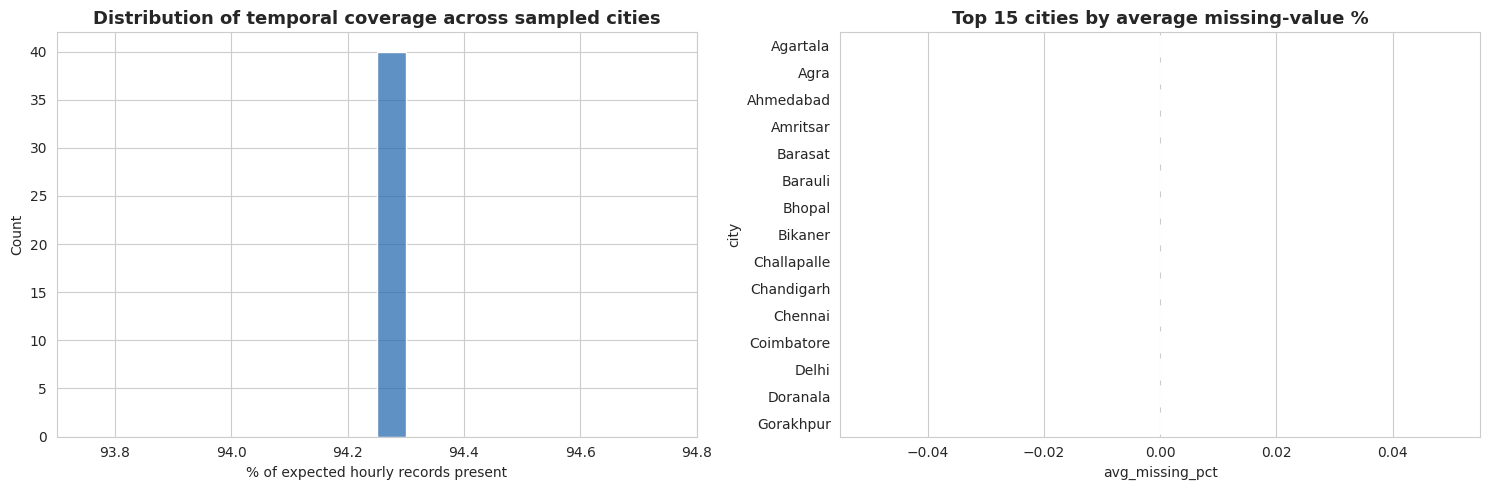


40/40 cities flagged for manual review (coverage < 95% or missingness > 2%).


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(quality_report["coverage_pct"], bins=20, ax=axes[0], color="#2b6cb0")
axes[0].set_title("Distribution of temporal coverage across sampled cities")
axes[0].set_xlabel("% of expected hourly records present")

top_missing = quality_report.nlargest(15, "avg_missing_pct")
sns.barplot(data=top_missing, y="city", x="avg_missing_pct", ax=axes[1], color="#e53e3e")
axes[1].set_title("Top 15 cities by average missing-value %")
plt.tight_layout()
plt.show()

n_review = (quality_report["quality_flag"] == "REVIEW").sum()
print(f"\n{n_review}/{len(quality_report)} cities flagged for manual review "
      f"(coverage < 95% or missingness > 2%).")

In [11]:
CITY_METADATA.to_csv(PROCESSED_DIR / "city_metadata.csv", index=False)
hourly.to_parquet(PROCESSED_DIR / "hourly_sample_raw.parquet", index=False)
print("Saved:")
print(" -", PROCESSED_DIR / "hourly_sample_raw.parquet", f"({hourly.shape})")
print(" -", PROCESSED_DIR / "city_metadata.csv")
print(" -", PROCESSED_DIR / "data_quality_report.csv")

Saved:
 - /kaggle/working/processed/hourly_sample_raw.parquet ((4957440, 23))
 - /kaggle/working/processed/city_metadata.csv
 - /kaggle/working/processed/data_quality_report.csv


In [ ]:
print("DATA LOADING & QUALITY ASSESSMENT -- SUMMARY")
print("=" * 55)
print(f"Cities sampled            : {len(SELECTED_CITIES)}")
print(f"Total hourly records      : {len(hourly):,}")
print(f"Date range in sample      : {hourly['time'].min()} -> {hourly['time'].max()}")
print(f"Avg temporal coverage     : {quality_report['coverage_pct'].mean():.1f}%")
print(f"Avg missing-value rate    : {quality_report['avg_missing_pct'].mean():.3f}%")
print(f"Cities flagged for review : {n_review}")
print(f"Cities failed to load     : {(load_log_df['status'] != 'ok').sum()}")